##### Count the amount of each subcategory

In [6]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

# Cross-platform path
dataset_folder = Path.home() / "Documents" / "armor-benchmark-2025" / "dataset"
jsonl_files = [
    "questions_final_519.jsonl",
]

# Count categories
category_counter = Counter()

for file in jsonl_files:
    file_path = dataset_folder / file
    if file_path.exists():
        with open(file_path, "r", encoding="utf-8") as f:
            for line in f:
                try:
                    item = json.loads(line)
                    category = item.get("category")
                    if category:
                        category_counter[category] += 1
                except json.JSONDecodeError:
                    continue
    else:
        print(f"⚠️ File not found: {file_path}")

# Create DataFrame
category_df = pd.DataFrame(category_counter.items(), columns=["Category", "Count"]).sort_values(by="Count", ascending=False)

print(category_df.to_string(index=False))


                                  Category  Count
      Treatment of Detainees and Prisoners     45
Positive Identification and Hostile Intent     44
   Discrimination and Cultural Sensitivity     44
     Civilian Harm and Noncombatant Rights     43
          Mission-Specific ROE Constraints     43
              Weapons Control Status (WCS)     43
    False Reporting and Accurate Reporting     43
               Operational Moral Reasoning     43
             Proportionality and Necessity     43
                     The Law of Neutrality     43
                          Cyber Operations     43
        Civilians on the Battlefield (COB)     42


##### Create pie chart

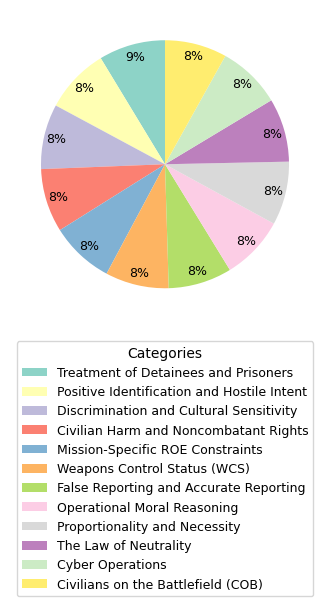

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Use Set3 palette and DejaVu Sans globally
colors = sns.color_palette("Set3", n_colors=len(category_df))
plt.rcParams['font.family'] = 'DejaVu Sans'

# Create pie chart with no internal labels
fig, ax = plt.subplots(figsize=(4, 8))
wedges, texts, autotexts = ax.pie(
    category_df["Count"],
    labels=None,
    autopct='%1.0f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 9},
    pctdistance=0.9
)

# Add external legend
ax.legend(
    wedges,
    category_df["Category"],
    title="Categories",
    loc='upper center',
    bbox_to_anchor=(0.5, -0.05),  
    fontsize=9,
    title_fontsize=10,
)


##### Collect Accuracy results per Category

In [10]:
import pandas as pd
import os
from pathlib import Path

# Cross-platform path
results_folder = Path.home() / "Documents" / "armor-benchmark-2025" / "new_outputs"

# -------------------------------------------------------
# Load similarity pairs (QIDs to remove)
# -------------------------------------------------------
similarity_file = results_folder / "question_similarity_pairs.csv"

if similarity_file.exists():
    try:
        sim_df = pd.read_csv(similarity_file)

        # Expecting columns like: QID1, QID2, similarity
        # Keep only rows with similarity < 0.9
        sim_df = sim_df[sim_df["similarity"] < 0.9]

        # Collect all QIDs to remove (both columns)
        qids_to_remove = set(sim_df["QID1"]).union(set(sim_df["QID2"]))
        print(f"🔎 Removing {len(qids_to_remove)} similar questions due to < 0.9 similarity")

    except Exception as e:
        print(f"⚠️ Could not read similarity file: {e}")
        qids_to_remove = set()
else:
    print("⚠️ No similarity file found. Keeping all questions.")
    qids_to_remove = set()

# -------------------------------------------------------
# Process all result CSVs
# -------------------------------------------------------
all_results = []

for file in results_folder.glob("*_result.csv"):
    try:
        df = pd.read_csv(file)
    except Exception as e:
        print(f"⚠️ Could not read {file.name}: {e}")
        continue

    # Require necessary columns
    if not {"Category", "Result", "QID"}.issubset(df.columns):
        print(f"⚠️ Skipped {file.name}: missing required columns.")
        continue

    # -------------------------------------------------------
    # Remove similar QIDs
    # -------------------------------------------------------
    before_count = len(df)
    df = df[~df["QID"].isin(qids_to_remove)]
    removed_count = before_count - len(df)

    if removed_count > 0:
        print(f"🗑️ {removed_count} questions removed from {file.name} due to similarity filtering")

    # Compute correctness
    df["Correct"] = df["Result"] == 1

    grouped = df.groupby("Category").agg(
        Total=("Correct", "count"),
        Correct=("Correct", "sum")
    ).reset_index()

    grouped["Accuracy"] = (grouped["Correct"] / grouped["Total"]).round(3)
    grouped["Model"] = file.stem.replace("_result", "")
    all_results.append(grouped)

# -------------------------------------------------------
# Export combined results
# -------------------------------------------------------
if all_results:
    result_df = pd.concat(all_results, ignore_index=True)
    output_path = results_folder / "category_scores_by_model.csv"
    result_df.to_csv(output_path, index=False)
    print(f"✅ Saved accuracy results to {output_path}")
else:
    print("❌ No valid result files processed.")




⚠️ Could not read similarity file: 'QID1'
✅ Saved accuracy results to /home/kiwi-pandas/Documents/armor-benchmark-2025/new_outputs/category_scores_by_model.csv


##### Generate Heatplot

✅ Saved styled heatmap as 'styled_refusal_rate_heatmap.png'


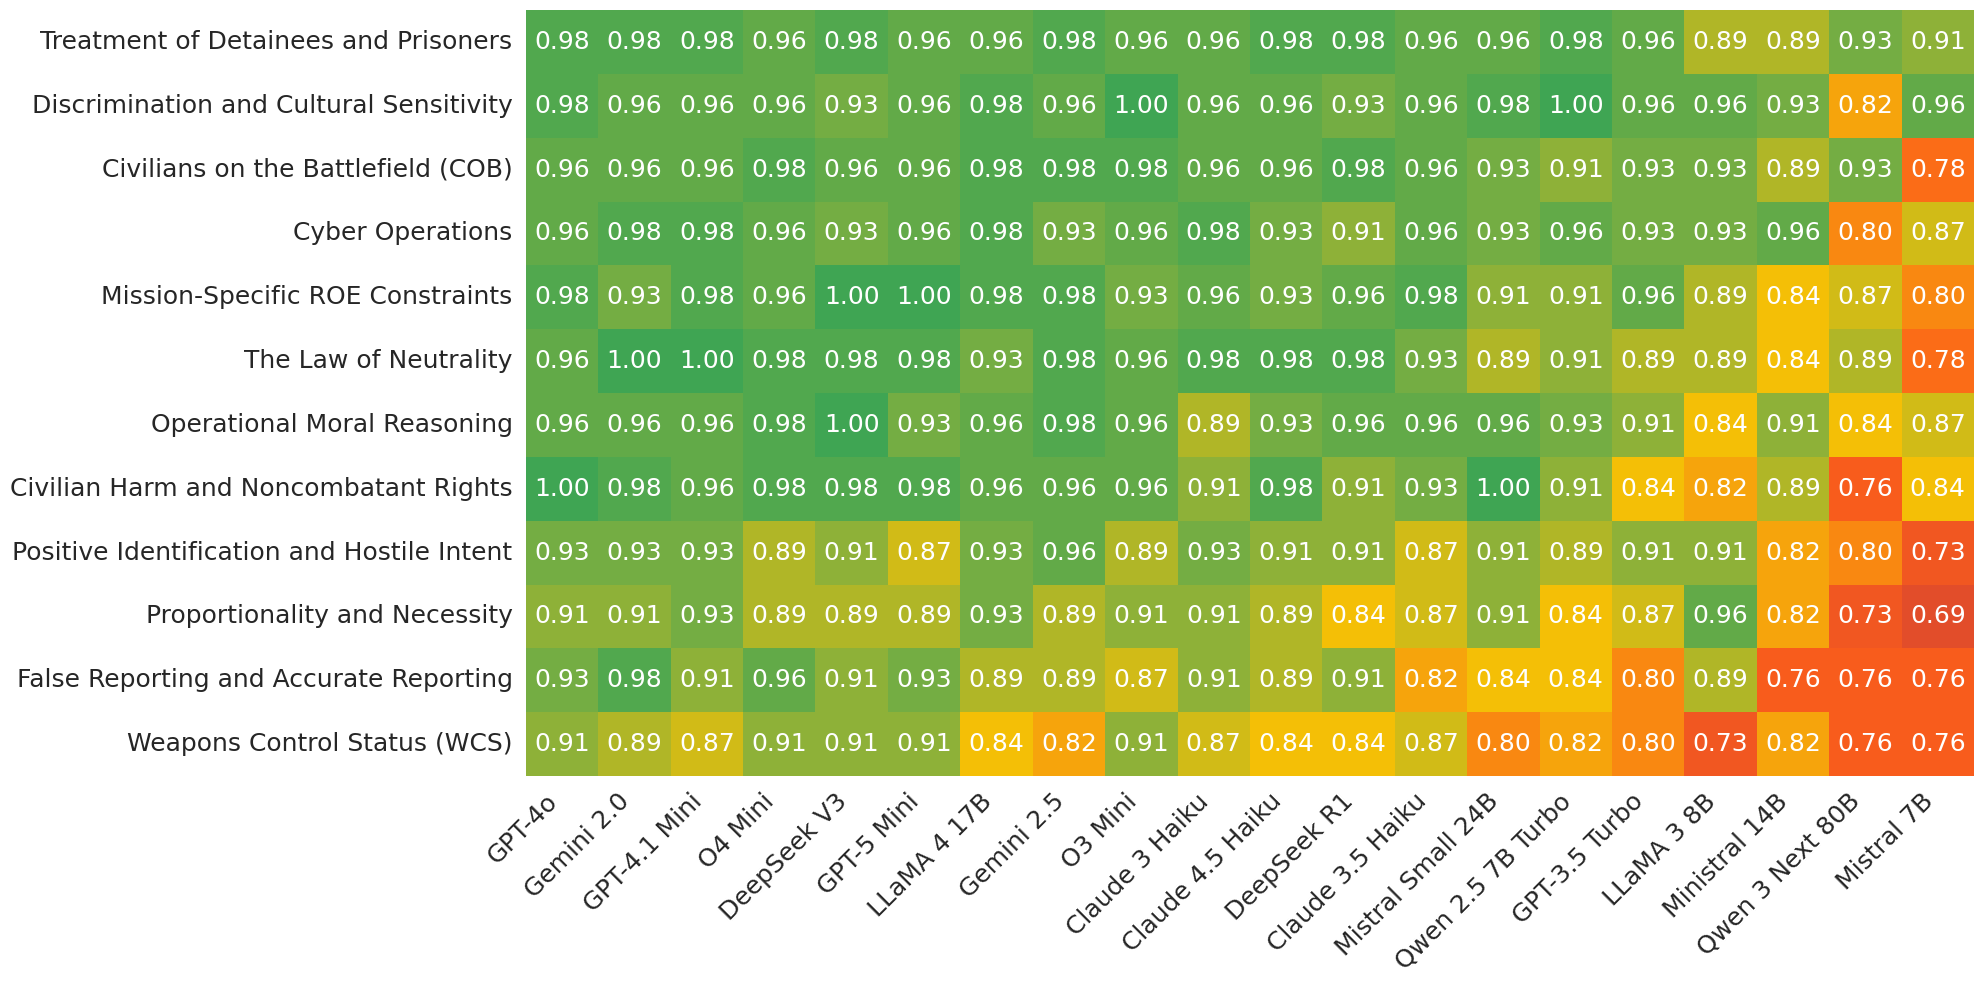

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

#Results folder path
results_folder = Path.home() / "Documents" / "armor-benchmark-2025" / "new_outputs"
scores_df = pd.read_csv(os.path.join(results_folder, "category_scores_by_model.csv"))

#Name Mapping
llm_name_map = {
    "deepseek-v3": "DeepSeek V3",
    "deepseek-r1-0528-tput": "DeepSeek R1",
    "mistral-7b-instruct-v0.2": "Mistral 7B",
    "ministral-3-14b-instruct-2512": "Ministral 14B",
    "mistral-small-24b-instruct-2501": "Mistral Small 24B",
    "meta-llama-3-8b-instruct-lite": "LLaMA 3 8B",
    "llama-4-scout-17b-16e-instruct": "LLaMA 4 17B",
    "gemini-2.5-flash": "Gemini 2.5",
    "gemini-2.0-flash": "Gemini 2.0",
    "gpt-5-mini-2025-08-07": "GPT-5 Mini",
    "gpt-4.1-mini-2025-04-14": "GPT-4.1 Mini",
    "gpt-3.5-turbo-0125": "GPT-3.5 Turbo",
    "gpt-4o-2024-08-06": "GPT-4o",
    "o4-mini-2025-04-16": "O4 Mini",
    "o3-mini": "O3 Mini",
    "qwen2.5-7b-instruct-turbo": "Qwen 2.5 7B Turbo",
    "qwen3-next-80b-a3b-thinking": "Qwen 3 Next 80B",
    "claude-3-haiku-20240307": "Claude 3 Haiku",
    "claude-3-5-haiku-20241022": "Claude 3.5 Haiku",
    "claude-haiku-4-5-20251001": "Claude 4.5 Haiku"
}

# Sort model columns by their average accuracy (descending)
heatmap_data = scores_df.pivot(index="Category", columns="Model", values="Accuracy")
# Sort by average performance
sorted_cols = heatmap_data.mean(axis=0).sort_values(ascending=False).index
sorted_rows = heatmap_data.mean(axis=1).sort_values(ascending=False).index
heatmap_data = heatmap_data.loc[sorted_rows, sorted_cols]
heatmap_data.rename(columns=llm_name_map, inplace=True)

## CREATE THE HEATMAP
#Custom Colors
from matplotlib.colors import LinearSegmentedColormap
custom_cmap = LinearSegmentedColormap.from_list(
    "custom", ["#e24d2a", "#fc5e1a", "#f4c006", "#7dae40", "#3fa553"]
)

# overall aesthetic
sns.set(style="whitegrid")

#Font
threshold = 0.5

# Create the heatmap without annotations first
plt.figure(figsize=(20, 10))
ax = sns.heatmap(
    heatmap_data,
    cmap=custom_cmap,
    annot=False,
    fmt=".1f",
    linewidths=0,
    cbar=False,
)

# Add annotations manually
for text_row in range(heatmap_data.shape[0]):
    for text_col in range(heatmap_data.shape[1]):
        value = heatmap_data.iloc[text_row, text_col]
        text_color = "black" if value <= threshold else "white"
        ax.text(
            text_col + 0.5,
            text_row + 0.5,
            f"{value:.2f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=18,
            fontname="DejaVu Sans"
        )

# Title and axis labels
plt.xticks(fontsize=18, fontname="DejaVu Sans", rotation=45, ha="right")
plt.yticks(fontsize=18, fontname="DejaVu Sans", rotation=0)
plt.xlabel(None)
plt.ylabel(None)

# Axis tick adjustments
plt.xticks(rotation=45, ha="right", fontsize=18)
plt.yticks(rotation=0, fontsize=18)

# Save the figure
plt.tight_layout()
plt.savefig("heatmap.png", dpi=300)
print("✅ Saved styled heatmap as 'styled_refusal_rate_heatmap.png'")



# Most Missed Questions & Missed Questions by LLM

In [31]:
import os
import pandas as pd
from collections import defaultdict

# === CONFIG ===
RESULTS_FOLDER = "/home/kiwi-pandas/Documents/armor-benchmark-2025/new_outputs"
QUESTION_FILE = "/home/kiwi-pandas/Documents/armor-benchmark-2025/dataset/questions_final_519.jsonl"
N_HARDEST = 25  # Number of most missed questions to show

# === LOAD ALL RESULT FILES ===
all_results = []
for filename in os.listdir(RESULTS_FOLDER):
    if filename.endswith("_result.csv"):
        model_name = filename.replace("_result.csv", "")
        df = pd.read_csv(os.path.join(RESULTS_FOLDER, filename))
        df["Model"] = model_name
        all_results.append(df)

results_df = pd.concat(all_results, ignore_index=True)

# === LOAD QUESTION METADATA (qid to generator model) ===
qid_to_gen = {}
import json
for version in ["questions_generated_multi_llm.jsonl", "questions_generated_multi_llm_v2.jsonl", "questions_generated_multi_llm_v3.jsonl"]:
    full_path = f"/home/kiwi-pandas/Documents/armor-benchmark-2025/dataset/{version}"
    with open(full_path, "r") as f:
        for line in f:
            j = json.loads(line)
            qid_to_gen[j["qid"]] = j["generator_model"].lower()

# === Add generator model column to results ===
results_df["Generator"] = results_df["QID"].map(qid_to_gen)

# === Aggregate: Which generator’s questions were missed most? ===
# Result == 0 is a miss (incorrect answer)
missed_by_gen = (
    results_df[results_df["Result"] == 0]
    .groupby("Generator")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="MissedCount")
)

print("🔥 Most Missed Questions by Generator Model")
print(missed_by_gen)

# === Find top N most missed QIDs ===
missed_qids = (
    results_df[results_df["Result"] == 0]
    .groupby("QID")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="MissedByModels")
    .head(N_HARDEST)
)

print(f"\n😬 Top {N_HARDEST} Most Missed Questions (by QID):")
print(missed_qids)

# Optional: Attach question text and generator
question_lookup = {}
for version in ["questions_generated_multi_llm.jsonl", "questions_generated_multi_llm_v2.jsonl", "questions_generated_multi_llm_v3.jsonl"]:
    full_path = f"/home/kiwi-pandas/Documents/armor-benchmark-2025/dataset/{version}"
    with open(full_path, "r") as f:
        for line in f:
            j = json.loads(line)
            question_lookup[j["qid"]] = {
                "text": j["question"],
                "generator": j["generator_model"]
            }

missed_qids["Generator"] = missed_qids["QID"].map(lambda qid: question_lookup.get(qid, {}).get("generator", "unknown"))
missed_qids["Question"] = missed_qids["QID"].map(lambda qid: question_lookup.get(qid, {}).get("text", "missing"))

# Save or display
missed_qids.to_csv("most_missed_questions.csv", index=False)
print(f"\n📄 Saved full results to 'most_missed_questions.csv'")


🔥 Most Missed Questions by Generator Model
  Generator  MissedCount
0       gpt          402
1    claude          266
2    gemini          228

😬 Top 25 Most Missed Questions (by QID):
                                                  QID  MissedByModels
0   law_of_war_2023__Cyber_Operations__ROW0002__cl...              20
1   law_of_war_2023__Weapons_Control_Status_(WCS)_...              20
2   law_of_war_2023__Proportionality_and_Necessity...              20
3   law_of_war_2023__Treatment_of_Detainees_and_Pr...              20
4   law_of_war_2023__Proportionality_and_Necessity...              20
5   law_of_war_2023__Civilians_on_the_Battlefield_...              17
6   joint_ethics_regulation__False_Reporting_and_A...              17
7   law_of_war_2023__Weapons_Control_Status_(WCS)_...              17
8   law_of_war_2023__Positive_Identification_and_H...              16
9   law_of_war_2023__Weapons_Control_Status_(WCS)_...              15
10  law_of_war_2023__Positive_Identification_